In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
house_data = pd.read_csv("raw_data/house_price.csv")

In [6]:
house_data.shape

(1000, 8)

In [7]:
house_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [8]:
house_data.sample(10)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
647,1023,4,1,1997,3.461247,2,2,287822.376878
98,1370,2,2,1973,3.148272,1,4,304730.506229
983,1013,1,1,1977,4.737096,1,7,248621.826149
534,857,5,3,1984,1.642720,1,4,252024.017681
363,2257,3,1,2002,1.637593,2,10,496427.103565
75,564,5,3,2018,2.844829,2,4,242865.931502
428,3940,4,2,1966,3.248468,0,7,842172.209238
926,2762,2,2,1976,4.510932,1,6,619407.627916
517,3784,4,1,2021,3.802474,1,5,870504.828591
642,1171,3,1,1958,0.693736,1,6,206781.757443


In [9]:
house_data.isna().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [10]:
house_data['Num_Bedrooms'].nunique()

5

In [11]:
house_data['Num_Bathrooms'].nunique()

3

In [12]:
house_data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='str')

<Axes: xlabel='Num_Bathrooms', ylabel='House_Price'>

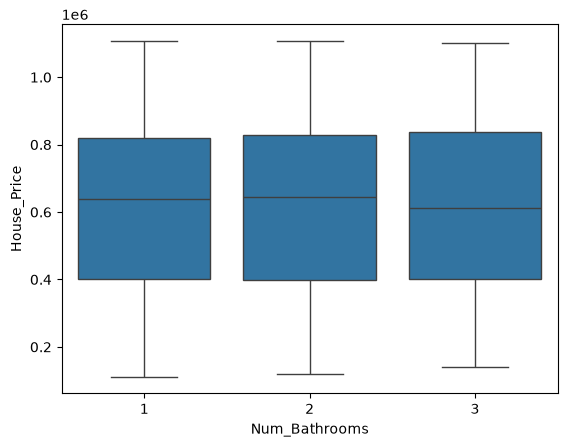

In [13]:
sns.boxplot(data=house_data,x= 'Num_Bathrooms',y = 'House_Price',)

<Axes: xlabel='Num_Bedrooms', ylabel='House_Price'>

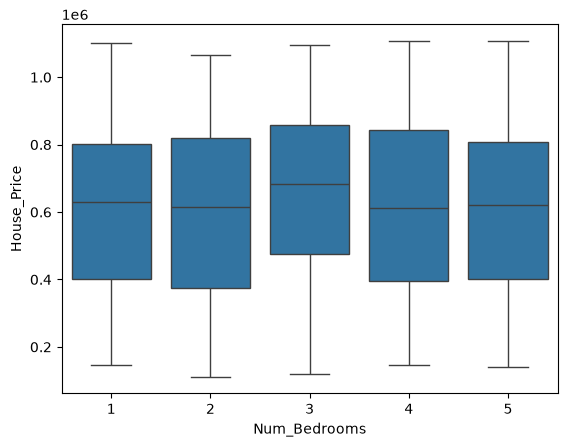

In [14]:
sns.boxplot(data=house_data,x = 'Num_Bedrooms',y = 'House_Price')

In [15]:
house_data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='str')

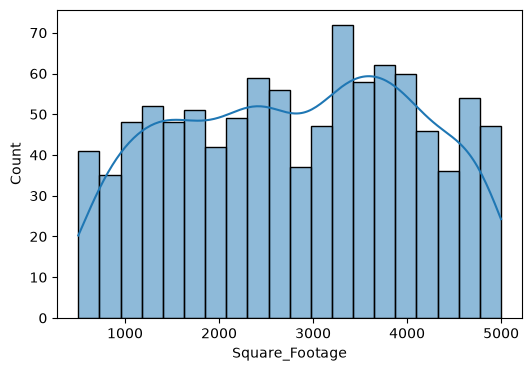

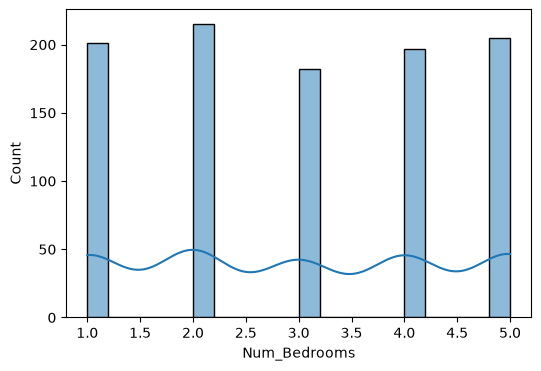

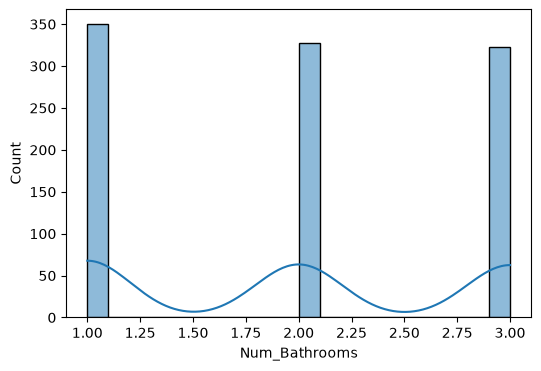

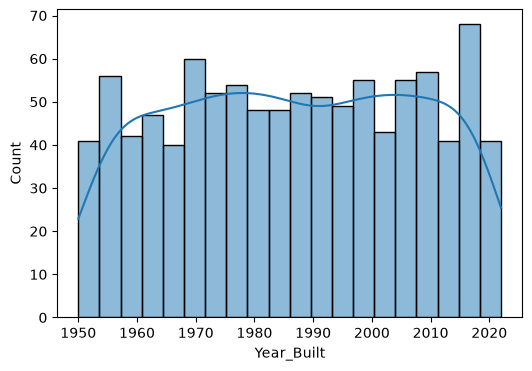

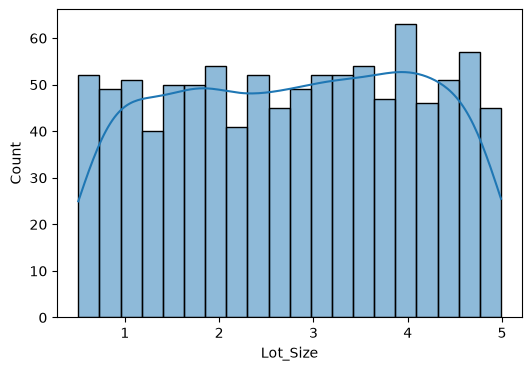

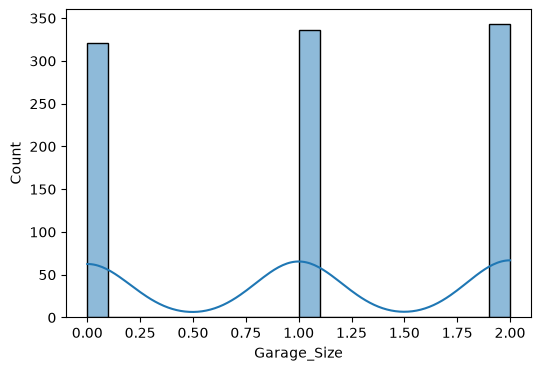

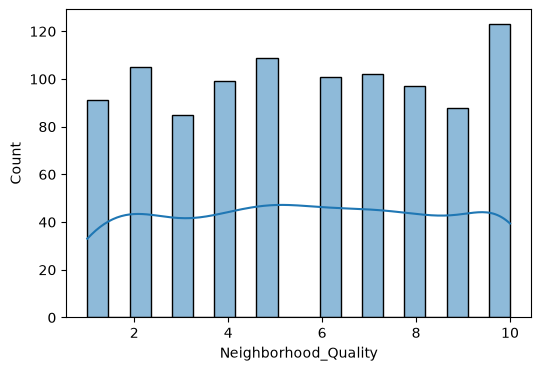

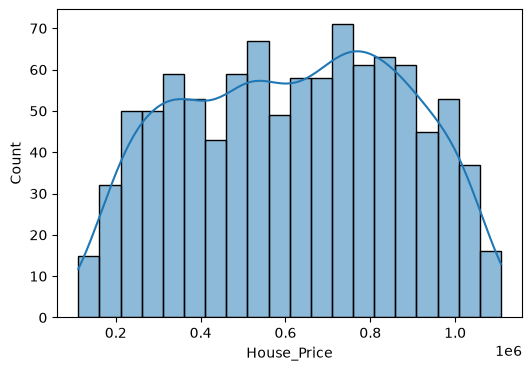

In [16]:
numbric_col = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price']
for col in numbric_col:
    plt.figure(figsize=(6,4))
    sns.histplot(house_data[col],kde=True,bins=20)

<Axes: xlabel='Neighborhood_Quality', ylabel='count'>

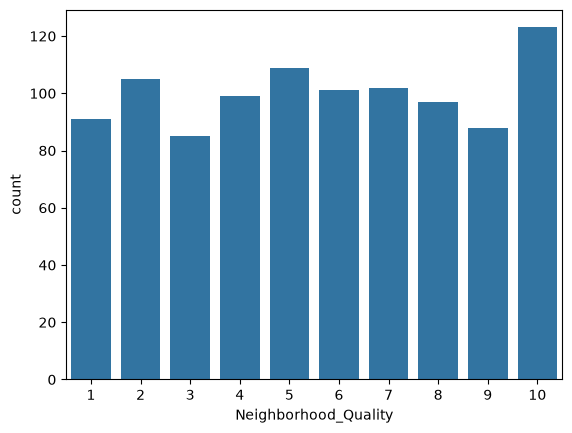

In [17]:
sns.countplot(x=house_data['Neighborhood_Quality'])

In [18]:
house_data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='str')

<Axes: xlabel='Square_Footage', ylabel='count'>

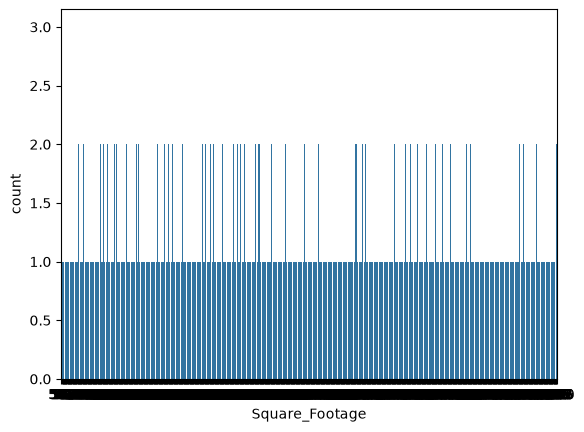

In [19]:
sns.countplot(x=house_data['Square_Footage'])

<Axes: xlabel='Year_Built', ylabel='count'>

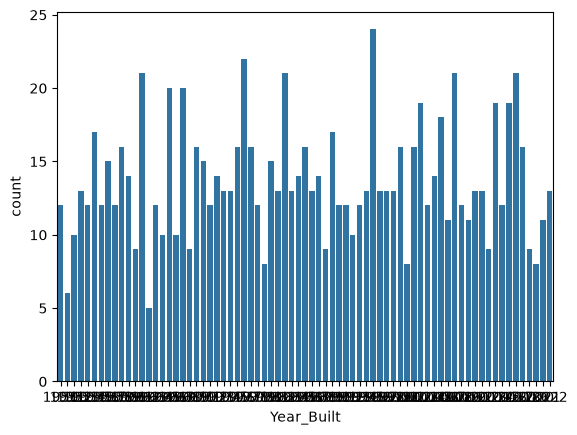

In [20]:
sns.countplot(x=house_data['Year_Built'])

In [21]:
house_data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='str')

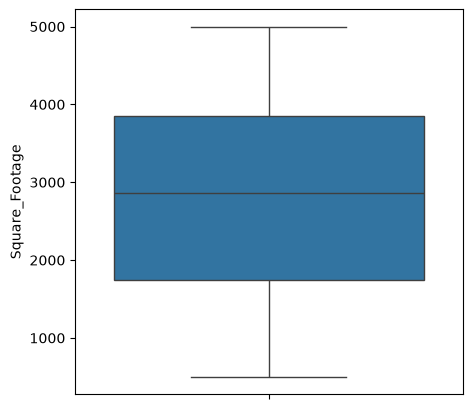

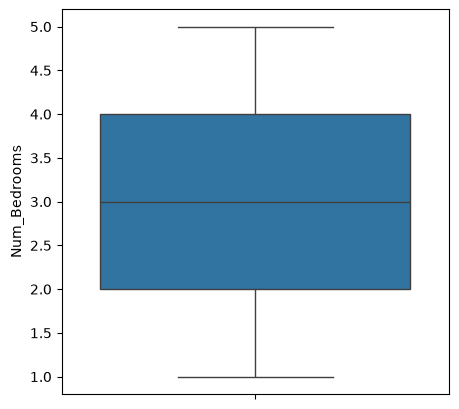

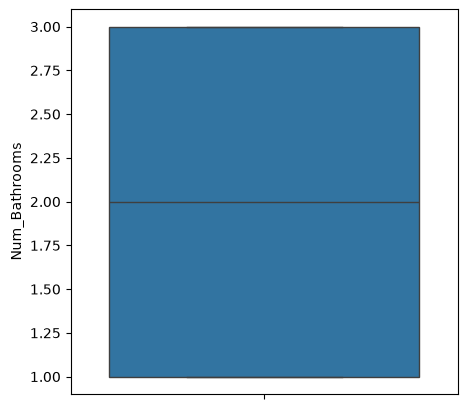

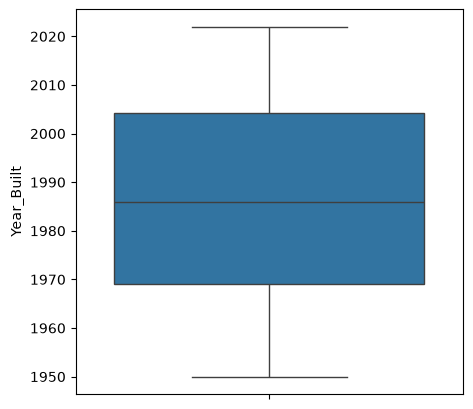

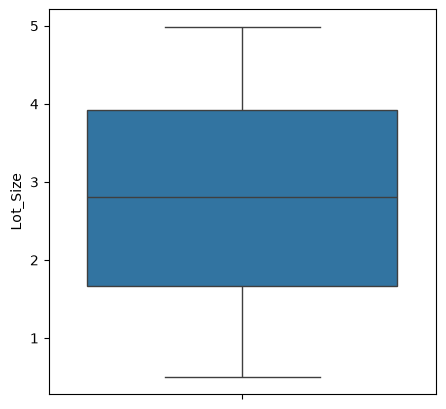

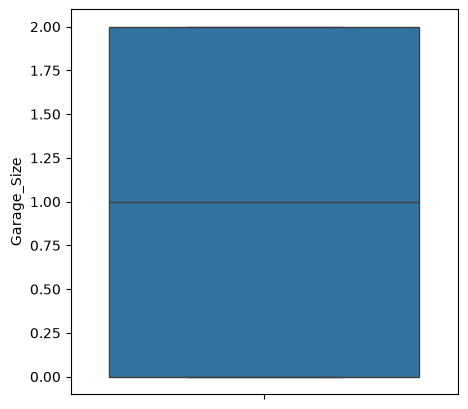

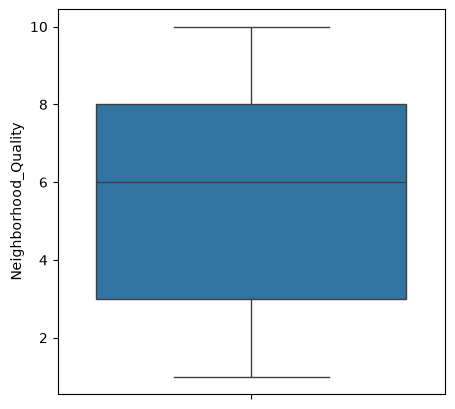

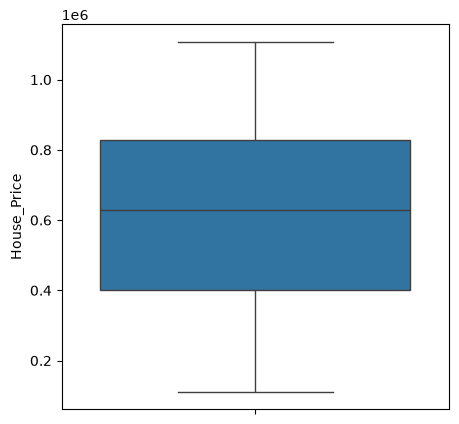

In [22]:
numbric_col= ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price']
for col in numbric_col:
    plt.figure(figsize=(5,5))
    sns.boxplot(house_data[col])

<Axes: >

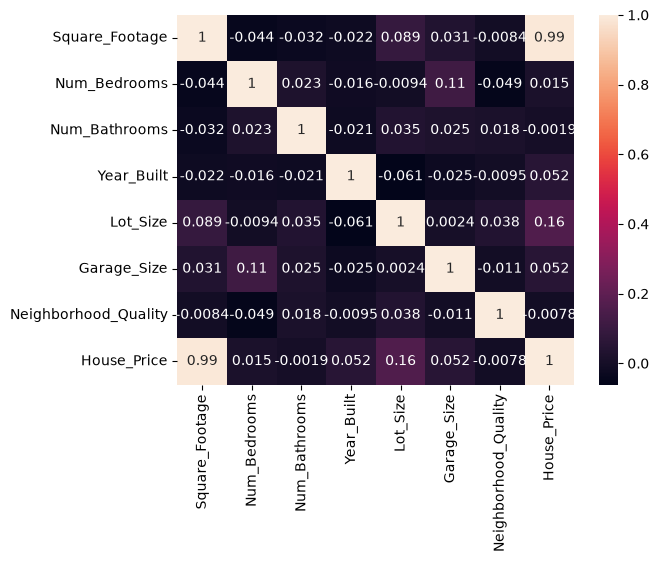

In [23]:
sns.heatmap(house_data.corr(numeric_only=True),annot=True)

##I'm going to take the vlues of [Sq_footge,Lot_Size,Year_bulit,garage_size]


In [24]:
X = house_data.drop(columns=['Neighborhood_Quality','House_Price','Num_Bathrooms'])
y = house_data['House_Price']

In [25]:
X.nunique()

Square_Footage     894
Num_Bedrooms         5
Year_Built          73
Lot_Size          1000
Garage_Size          3
dtype: int64

In [26]:
X = pd.get_dummies(X,columns=['Garage_Size','Num_Bedrooms'],drop_first=True)

In [27]:
X.astype(int)

,Square_Footage,Year_Built,Lot_Size,Garage_Size_1,Garage_Size_2,Num_Bedrooms_2,Num_Bedrooms_3,Num_Bedrooms_4,Num_Bedrooms_5
0,1360,1981,0,0,0,1,0,0,0
1,4272,2016,4,1,0,0,1,0,0
2,3592,2016,3,0,0,0,0,0,0
3,966,1977,2,1,0,0,0,0,0
4,4926,1993,4,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...
995,3261,1978,2,0,1,0,0,1,0
996,3179,1999,2,1,0,0,0,0,0
997,2606,1962,4,0,0,0,0,1,0
998,4723,1950,1,0,0,0,0,0,1


In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
col = ['Square_Footage','Year_Built','Lot_Size']
X[col] = scaler.fit_transform(X[col])

In [41]:
X.sample(10)

,Square_Footage,Year_Built,Lot_Size,Garage_Size_1,Garage_Size_2,Num_Bedrooms_2,Num_Bedrooms_3,Num_Bedrooms_4,Num_Bedrooms_5
484,0.657890,1.282574,-1.099104,False,True,False,False,False,False
130,-1.280133,1.185593,0.838067,False,True,False,False,False,True
793,-0.142979,1.718988,0.908023,True,False,False,False,True,False
938,-0.199557,0.846159,-1.341340,False,True,False,False,False,False
156,0.951941,-0.317613,0.582829,True,False,False,False,False,False
657,0.448310,0.070311,-0.804281,True,False,False,False,False,True
261,0.681000,1.234083,-0.550629,True,False,False,True,False,False
984,-0.315106,-0.657046,0.081422,False,True,False,False,False,True
474,-0.739048,-0.220632,1.501168,False,True,False,False,False,True
92,-0.594015,1.234083,0.122814,False,True,False,True,False,False


In [45]:
col = ['Garage_Size_1','Garage_Size_2', 'Num_Bedrooms_2', 'Num_Bedrooms_3', 'Num_Bedrooms_4','Num_Bedrooms_5']
X[col] = X[col].astype(int)

In [46]:
X.sample()

,Square_Footage,Year_Built,Lot_Size,Garage_Size_1,Garage_Size_2,Num_Bedrooms_2,Num_Bedrooms_3,Num_Bedrooms_4,Num_Bedrooms_5
202,-0.504764,-1.626856,-0.498859,0,1,0,1,0,0


In [47]:
X.columns

Index(['Square_Footage', 'Year_Built', 'Lot_Size', 'Garage_Size_1',
       'Garage_Size_2', 'Num_Bedrooms_2', 'Num_Bedrooms_3', 'Num_Bedrooms_4',
       'Num_Bedrooms_5'],
      dtype='str')

In [50]:
y.head()

0    2.623829e+05
1    9.852609e+05
2    7.779774e+05
3    2.296989e+05
4    1.041741e+06
Name: House_Price, dtype: float64

In [51]:
from scipy.stats import pearsonr

# Pearson Correlation Calculation

# List of features to check against target
selected_features = ['Square_Footage', 'Year_Built', 'Lot_Size', 'Garage_Size_1',
       'Garage_Size_2', 'Num_Bedrooms_2', 'Num_Bedrooms_3', 'Num_Bedrooms_4',
       'Num_Bedrooms_5']
correlations = {
feature: pearsonr(X[feature], house_data['House_Price'])[0]
for feature in selected_features
}
correlation_data = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_data.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
0,Square_Footage,0.991261
2,Lot_Size,0.160412
6,Num_Bedrooms_3,0.064453
4,Garage_Size_2,0.055226
1,Year_Built,0.051967
7,Num_Bedrooms_4,0.004498
8,Num_Bedrooms_5,-0.011982
3,Garage_Size_1,-0.021102
5,Num_Bedrooms_2,-0.036211


In [53]:
X.sample()

,Square_Footage,Year_Built,Lot_Size,Garage_Size_1,Garage_Size_2,Num_Bedrooms_2,Num_Bedrooms_3,Num_Bedrooms_4,Num_Bedrooms_5
968,1.328867,-0.754027,-0.813293,1,0,0,1,0,0


In [54]:
y

0      2.623829e+05
1      9.852609e+05
2      7.779774e+05
3      2.296989e+05
4      1.041741e+06
           ...     
995    7.014940e+05
996    6.837232e+05
997    5.720240e+05
998    9.648653e+05
999    7.425993e+05
Name: House_Price, Length: 1000, dtype: float64

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [62]:
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[249936.32, 20465.92, 19420.81,..., 21154.36, 31209.64, 41693.96]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Square_Footage','Year_Built','Lot_Size',...,'Num_Bedrooms_3', 'Num_Bedrooms_4','Num_Bedrooms_5']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.919e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


In [64]:
y_pred = lr.predict(X_test)
y_test


521    9.010005e+05
737    4.945375e+05
740    9.494042e+05
660    1.040389e+06
411    7.940100e+05
           ...     
506    4.314233e+05
342    8.946111e+05
485    8.277412e+05
711    4.722920e+05
133    2.440304e+05
Name: House_Price, Length: 330, dtype: float64

In [65]:
y_pred

array([ 876303.89083437,  498622.91877565,  935614.48192933,
       1042119.17078736,  782744.97676969,  731621.45304133,
        986063.79027493,  885111.1978165 ,  804186.99858074,
        940168.08716136,  758369.89142843,  652319.33677854,
        227841.40106408, 1039295.61649659,  544399.67524148,
        187554.37381786,  455761.09759815,  366731.09481784,
        751080.10817578,  362879.77781382,  783433.85374241,
        486181.30037797,  688928.46646638,  880467.30264887,
        438239.62097224,  388953.62546123,  462624.64450768,
        443448.53909211,  178535.80263016,  483096.09525555,
        272126.03748145,  888251.14994965,  774393.61917655,
        360069.74238767,  487767.79451809,  764552.30188943,
        464693.08625373,  572065.88432229,  312697.90366677,
        162774.17753734,  296336.09624158,  300300.26644029,
        507706.823862  ,  317178.3252997 , 1080976.02321126,
       1011190.65535616,  758626.87046711,  807779.85459612,
       1016106.70299963,

In [67]:
r2 = r2_score(y_test,y_pred)
r2

0.9977488310723291

In [68]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.9976855169462384